### Intermediate Project

Name: Rajasekar Babu

Course: DATA 110

####Project Title Email Spam Detection Using Machine Learning




###Step 1: Import Libraries
###Step 2: Load the Dataset
###Step 3: Data Understanding and Exploration
###Step 4: Data Cleaning
###Step 5: Data Visualization
###Step 6: Feature Selection
###Step 7: Train-Test Split
###Step 8: Model Building
###8.1 Naive Bayes
###8.2 Logistic Regression
###8.3 Support Vector Machine
###Step 9: Model Evaluation
###Step 10: Confusion Matrix
###Step 11: Model Comparison
###Step 12: Conclusion

In [1]:
###Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [38]:
###Step 2: Load the Dataset
df = pd.read_csv("emails.csv")
df.head()


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In this step, the email spam dataset was loaded into the notebook. The first five rows were displayed to understand the data.

###Step 3: Data Understanding and Exploration

```
# This is formatted as code
```



In [3]:

df.shape

(692, 3002)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692 entries, 0 to 691
Columns: 3002 entries, Email No. to Prediction
dtypes: float64(2727), int64(274), object(1)
memory usage: 15.8+ MB


In [6]:
df.isnull().sum()

,0
Email No.,0
the,0
to,0
ect,0
and,0
...,...
military,1
allowing,1
ff,1
dry,1


In [7]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.dropna()

###In this step, the structure of the dataset was examined. The number of rows and columns, data types, missing values, and duplicate records were checked.

In [27]:
###Step 4: Data Cleaning

# Clean
df = df.drop_duplicates()

# Split features
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]





###Duplicate rows were removed from the dataset to improve data quality. No unnecessary repeated records were kept.

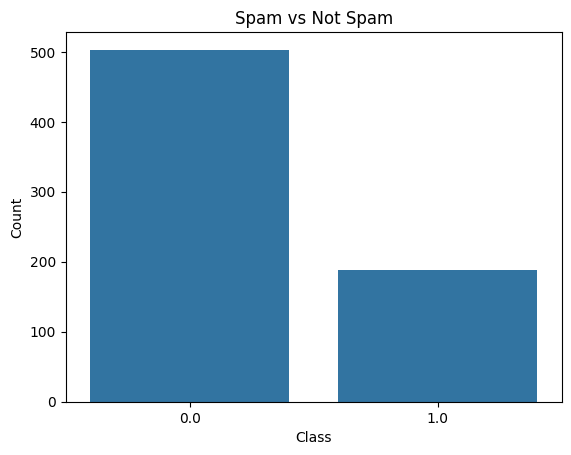

,count
Prediction,
0.0,503
1.0,188


In [9]:
###Step 5: Data Visualization
sns.countplot(x=df.iloc[:, -1])
plt.title("Spam vs Not Spam")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()
df.iloc[:, -1].value_counts()

###The count plot shows the distribution of spam and non-spam emails in the dataset. It can be observed that non-spam emails are more frequent than spam emails. This indicates that the dataset is slightly imbalanced, with a higher number of normal emails compared to spam emails.

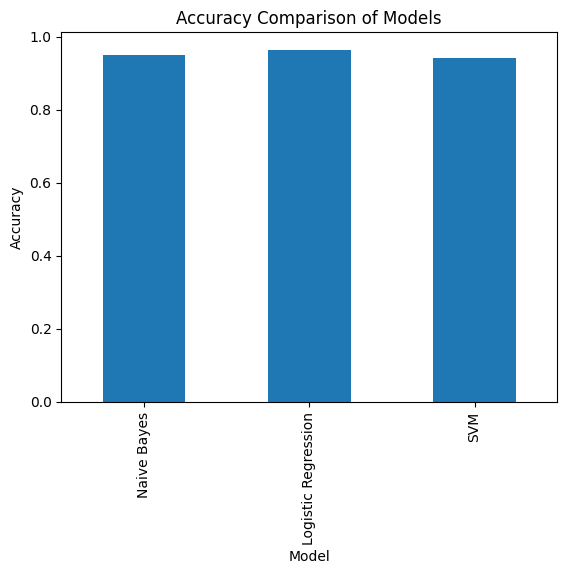

In [44]:
###graph
results.plot(x="Model", y="Accuracy", kind="bar", legend=False)
plt.title("Accuracy Comparison of Models")
plt.ylabel("Accuracy")
plt.show()

###The bar chart compares the accuracy of different machine learning models used in this project. It can be seen that all models performed well, with Logistic Regression achieving the highest accuracy. This shows that Logistic Regression is the most effective model for this dataset.

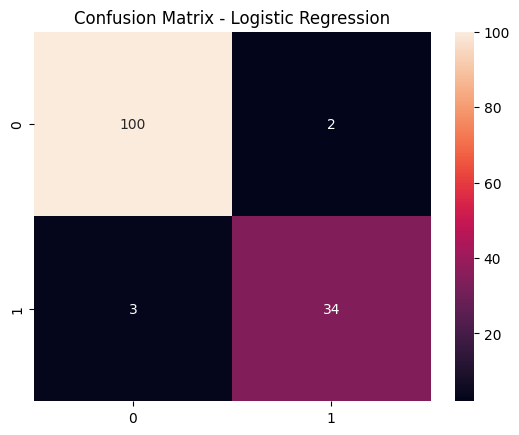

In [45]:
###HeatMap
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

###The confusion matrix shows the performance of the Logistic Regression model. It displays the number of correct and incorrect predictions made by the model. Most of the emails were correctly classified, with very few misclassifications. This indicates that the model has high accuracy and performs well in detecting spam emails.

###Overall, the visualizations help in understanding the dataset distribution and model performance more clearly.

In [11]:
###Step 6: Feature Selection
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

###The input features were stored in X, and the target variable was stored in y. The target column represents whether an email is spam or not spam.

In [16]:
###Step 7: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###The dataset was divided into training and testing sets. Eighty percent of the data was used for training and twenty percent was used for testing.

In [ ]:
###Step 8: Model Building

In [28]:
###8.1 Naive Bayes
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)


###The Naive Bayes model was trained using the training data.

In [29]:
###8.2 Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

###The Logistic Regression model was trained to classify emails as spam or not spam.

In [33]:
###8.3 Support Vector Machine
from sklearn.svm import LinearSVC
svm_model = LinearSVC(max_iter=10000)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

In [34]:
###Step 9: Model Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(name, y_test, y_pred):
    print("-----", name, "-----")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print()

evaluate_model("Naive Bayes", y_test, nb_pred)
evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("SVM", y_test, svm_pred)

----- Naive Bayes -----
Accuracy: 0.9496402877697842
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.97       102
         1.0       0.89      0.92      0.91        37

    accuracy                           0.95       139
   macro avg       0.93      0.94      0.94       139
weighted avg       0.95      0.95      0.95       139

[[98  4]
 [ 3 34]]

----- Logistic Regression -----
Accuracy: 0.9640287769784173
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98       102
         1.0       0.94      0.92      0.93        37

    accuracy                           0.96       139
   macro avg       0.96      0.95      0.95       139
weighted avg       0.96      0.96      0.96       139

[[100   2]
 [  3  34]]

----- SVM -----
Accuracy: 0.9424460431654677
              precision    recall  f1-score   support

         0.0       0.97      0.95      0.96       102
         1.0       0.87      0.92 

###The models were evaluated using accuracy, precision, recall, F1-score, and confusion matrix.

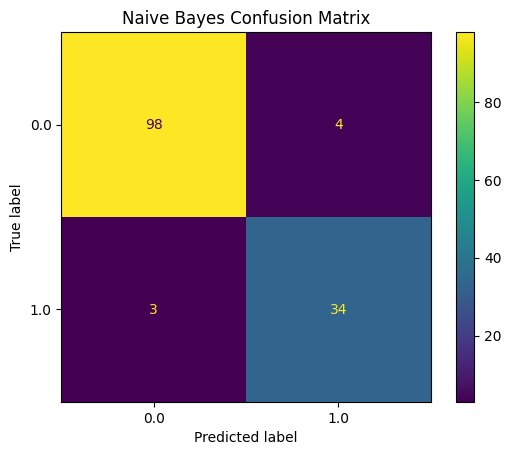

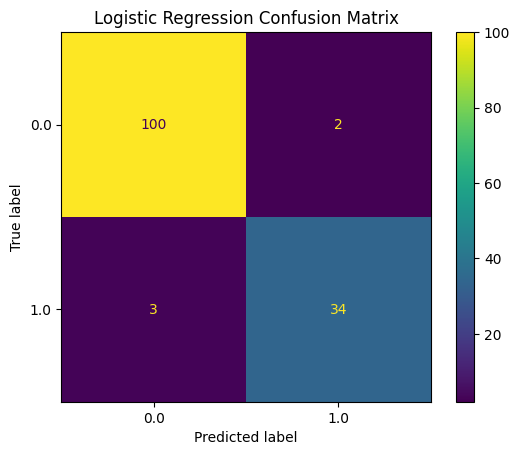

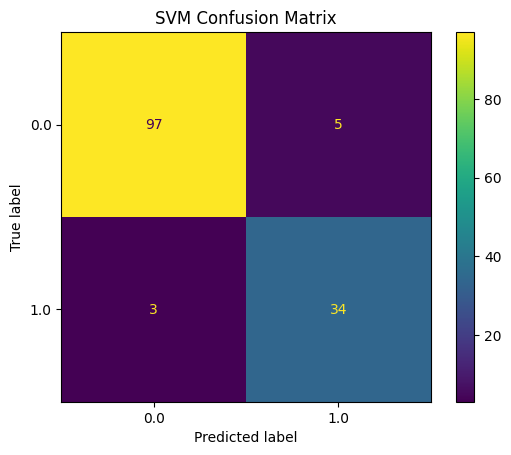

In [35]:
###Step 10: Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, nb_pred)
plt.title("Naive Bayes Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, svm_pred)
plt.title("SVM Confusion Matrix")
plt.show()

###The confusion matrix was used to show the number of correct and incorrect predictions made by each model.

In [36]:
###Step 11: Model Comparison
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

results

,Model,Accuracy
0,Naive Bayes,0.949640
1,Logistic Regression,0.964029
2,SVM,0.942446


###The performance of all models was compared. The model with the highest accuracy was selected as the best model.

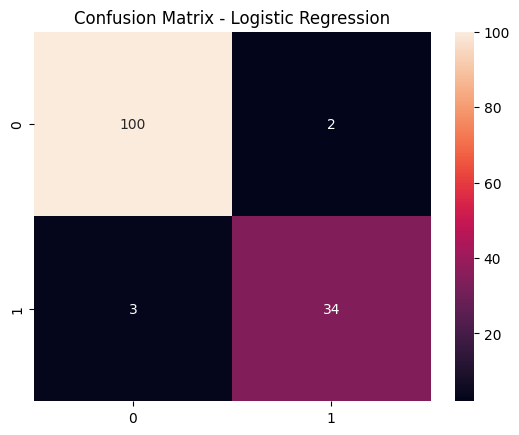

In [41]:
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

###Step 12: Conclusion

In this project, an email spam detection system was developed using machine learning techniques. The dataset consisted of 691 emails, where 503 (72.8%) were non-spam and 188 (27.2%) were spam, indicating a slight class imbalance in the data.

Three machine learning models - Naive Bayes, Logistic Regression, and Support Vector Machine (SVM) — were trained and evaluated to classify emails. The performance of these models was assessed using accuracy, precision, recall, and F1-score.

Among the models, Logistic Regression achieved the highest accuracy of 96.4%, outperforming Naive Bayes (94.9%) and SVM (94.2%). It also showed strong performance in precision (0.94), recall (0.92), and F1-score (0.93) for spam detection, indicating that the model is highly effective in correctly identifying spam emails while minimizing errors.

The confusion matrix further confirmed that most emails were correctly classified, with very few false positives and false negatives. This demonstrates that the model is reliable and performs well on unseen data.

Overall, this project shows that machine learning models can successfully classify emails as spam or not spam with high accuracy. Logistic Regression proved to be the most suitable model for this dataset due to its superior performance across all evaluation metrics.

In future work, the model can be improved by using larger datasets, applying advanced feature engineering techniques, and experimenting with more complex algorithms to further enhance performance.